# Plot simulation

- effect of season (6 and 9)

- effect of diurnal cycle (1200, 1500, 1800)

In [1564]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle                
import cartopy.crs as ccrs                              
import cartopy.feature as cfeature                   
import tensorflow as tf                                                                 
from joblib import load             
from scipy.ndimage import gaussian_filter                                              
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'                    # '0'=all, '1'=info, '2'=warning, '3'=error
from scipy.special import expit  # sigmoid

# Choose the lead time and the classification threshold

In [1565]:
year = 2020
day = 15
month = 9
hour = 18
minute = 0

# Extreme test

In [1566]:
PC = {
  "0000": 0.005891805,
  "0100": 0.0058949627,
  "0200": 0.006966774,
  "0300": 0.0069630425,
  "0400": 0.0075026797,
  "0500": 0.005891805,
  "0600": 0.006430868,
  "0700": 0.0069630425,
  "0800": 0.005891805,
  "0900": 0.004823151,
  "1000": 0.0037493305,
  "1100": 0.0005353319,
  "1200": 0.0032137118,
  "1300": 0.005353319,
  "1400": 0.004284949,
  "1500": 0.0069630425,
  "1600": 0.01124197,
  "1700": 0.010712373,
  "1800": 0.016059957,
  "1900": 0.011771001,
  "2000": 0.009630819,
  "2100": 0.009095773,
  "2200": 0.009100642,
  "2300": 0.0058855005
}

In [1567]:
lead_time = 3

In [1568]:
lead_hour = f"{(hour+lead_time)%24:02d}{minute:02d}"
pc = PC[lead_hour]

In [1569]:
lead_time_map = {
    1: 1.0151,
    3: 1.0901,
    6: 0.7988
}

temperature = lead_time_map.get(lead_time)


In [1570]:
resolution = 0.01

# Load artificial data

In [1571]:
test = pd.read_csv(f'/localhome/home/mmmhr/EPS-Impact-Case-AI-Nowcasting/notebook/simulation/data/single/artificial-mcs-data-{resolution}.csv')

In [1572]:
test

,year,month,day,hour,minute,lat1,lat2,lat3,lon1,lon2,...,wp3,size1,size2,size3,d1,d2,d3,mask1,mask2,mask3
0,2020,9,5,15,0,11.00,11.099343,11.129538,-20.00,-20.027653,...,130.407826,936.724128,936.724128,936.724128,496.111327,488.613648,466.226726,1,1,1
1,2020,9,5,15,0,11.00,10.953169,11.315843,-19.99,-20.036827,...,130.407826,936.724128,936.724128,936.724128,495.512544,502.671183,456.989695,1,1,1
2,2020,9,5,15,0,11.00,10.906105,10.907316,-19.98,-19.871488,...,130.407826,936.724128,936.724128,936.724128,494.915409,497.430817,509.110462,1,1,1
3,2020,9,5,15,0,11.00,11.048392,10.655016,-19.97,-20.352656,...,130.407826,936.724128,936.724128,936.724128,494.319929,513.937513,533.286005,1,1,1
4,2020,9,5,15,0,11.00,10.797434,10.818395,-19.96,-19.897151,...,130.407826,936.724128,936.724128,936.724128,493.726111,509.224202,527.638544,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
639995,2020,9,5,15,0,18.99,18.674526,19.375836,-12.05,-12.014817,...,130.407826,936.724128,936.724128,936.724128,746.977471,728.550186,759.044573,1,1,1
639996,2020,9,5,15,0,18.99,19.103555,18.732978,-12.04,-12.254357,...,130.407826,936.724128,936.724128,936.724128,747.798571,738.480254,747.253998,1,1,1
639997,2020,9,5,15,0,18.99,18.674431,18.929756,-12.03,-11.978680,...,130.407826,936.724128,936.724128,936.724128,748.620282,731.613856,704.110111,1,1,1
639998,2020,9,5,15,0,18.99,19.068183,19.137513,-12.02,-11.722891,...,130.407826,936.724128,936.724128,936.724128,749.442601,779.404495,780.483724,1,1,1


In [1573]:
test["year"] = year
test["day"] = day
test["month"] = month
test["hour"] = hour
test["minute"] = minute

In [1574]:
input_headers = ['year', 'month', 'day', 'hour', 'minute']    
for prefix in ['lat', 'lon', 'wp', 'size', 'd', 'mask']:
    input_headers.extend([f'{prefix}{i}' for i in range(1, 4)])

In [1575]:
X_test = test[input_headers]

In [1576]:
for col in ['size1', 'size2', 'size3', 'wp1', 'wp2', 'wp3', 'd1', 'd2', 'd3']:
    X_test.loc[:, col] = np.log1p(X_test[col])

In [1577]:
# sqrt transform for t0 (temporal) features
for col in ['year', 'month', 'day', 'hour', 'minute']:
    X_test.loc[:, col] = np.sqrt(X_test[col])

In [1578]:
X_test

,year,month,day,hour,minute,lat1,lat2,lat3,lon1,lon2,...,wp3,size1,size2,size3,d1,d2,d3,mask1,mask2,mask3
0,44.94441,3,3.872983,4.242641,0,11.00,11.099343,11.129538,-20.00,-20.027653,...,4.878306,6.843456,6.843456,6.843456,6.208814,6.193617,6.146815,1,1,1
1,44.94441,3,3.872983,4.242641,0,11.00,10.953169,11.315843,-19.99,-20.036827,...,4.878306,6.843456,6.843456,6.843456,6.207609,6.221924,6.126847,1,1,1
2,44.94441,3,3.872983,4.242641,0,11.00,10.906105,10.907316,-19.98,-19.871488,...,4.878306,6.843456,6.843456,6.843456,6.206405,6.211465,6.234627,1,1,1
3,44.94441,3,3.872983,4.242641,0,11.00,11.048392,10.655016,-19.97,-20.352656,...,4.878306,6.843456,6.843456,6.843456,6.205204,6.244046,6.280931,1,1,1
4,44.94441,3,3.872983,4.242641,0,11.00,10.797434,10.818395,-19.96,-19.897151,...,4.878306,6.843456,6.843456,6.843456,6.204004,6.234850,6.270305,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
639995,44.94441,3,3.872983,4.242641,0,18.99,18.674526,19.375836,-12.05,-12.014817,...,4.878306,6.843456,6.843456,6.843456,6.617373,6.592428,6.633377,1,1,1
639996,44.94441,3,3.872983,4.242641,0,18.99,19.103555,18.732978,-12.04,-12.254357,...,4.878306,6.843456,6.843456,6.843456,6.618470,6.605948,6.617742,1,1,1
639997,44.94441,3,3.872983,4.242641,0,18.99,18.674431,18.929756,-12.03,-11.978680,...,4.878306,6.843456,6.843456,6.843456,6.619567,6.596619,6.558354,1,1,1
639998,44.94441,3,3.872983,4.242641,0,18.99,19.068183,19.137513,-12.02,-11.722891,...,4.878306,6.843456,6.843456,6.843456,6.620663,6.659812,6.661194,1,1,1


# Scaling

In [1579]:
# Exclude mask columns from scaling
mask_cols = ['mask1', 'mask2', 'mask3']

# Final list of features to scale
cols_to_scale = [col for col in X_test.columns 
                 if col not in mask_cols]

scaler = load(f'../../model/dakar/lead-time-t{lead_time}/model-dakar-t{lead_time}-corrected.pkl')

X_test_scaled = X_test.copy()
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

In [1580]:
X_test_scaled

,year,month,day,hour,minute,lat1,lat2,lat3,lon1,lon2,...,wp3,size1,size2,size3,d1,d2,d3,mask1,mask2,mask3
0,2.008071,1.105652,0.027622,0.692884,-1.591422,-1.198698,-0.760492,-0.472654,-2.130005,-2.026752,...,0.102307,-0.139233,-0.015892,0.031117,0.863122,0.498214,-0.063499,1,1,1
1,2.008071,1.105652,0.027622,0.692884,-1.591422,-1.198698,-0.829344,-0.397223,-2.124653,-2.030866,...,0.102307,-0.139233,-0.015892,0.031117,0.861459,0.555242,-0.113177,1,1,1
2,2.008071,1.105652,0.027622,0.692884,-1.591422,-1.198698,-0.851513,-0.562626,-2.119301,-1.956725,...,0.102307,-0.139233,-0.015892,0.031117,0.859798,0.534172,0.154969,1,1,1
3,2.008071,1.105652,0.027622,0.692884,-1.591422,-1.198698,-0.784491,-0.664776,-2.113950,-2.172489,...,0.102307,-0.139233,-0.015892,0.031117,0.858139,0.599809,0.270169,1,1,1
4,2.008071,1.105652,0.027622,0.692884,-1.591422,-1.198698,-0.902701,-0.598628,-2.108598,-1.968232,...,0.102307,-0.139233,-0.015892,0.031117,0.856483,0.581284,0.243731,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
639995,2.008071,1.105652,0.027622,0.692884,-1.591422,3.261357,2.807663,2.866069,2.124552,1.566350,...,0.102307,-0.139233,-0.015892,0.031117,1.427100,1.301666,1.147015,1,1,1
639996,2.008071,1.105652,0.027622,0.692884,-1.591422,3.261357,3.009750,2.605792,2.129904,1.458936,...,0.102307,-0.139233,-0.015892,0.031117,1.428614,1.328903,1.108118,1,1,1
639997,2.008071,1.105652,0.027622,0.692884,-1.591422,3.261357,2.807618,2.685462,2.135256,1.582554,...,0.102307,-0.139233,-0.015892,0.031117,1.430128,1.310109,0.960366,1,1,1
639998,2.008071,1.105652,0.027622,0.692884,-1.591422,3.261357,2.993088,2.769578,2.140607,1.697255,...,0.102307,-0.139233,-0.015892,0.031117,1.431642,1.437419,1.216222,1,1,1


# Loading models

In [1581]:
model = tf.keras.models.load_model(f'../../model/dakar/lead-time-t{lead_time}/model-dakar-t{lead_time}-corrected.keras')

# Inference

In [1582]:
y_pred = model.predict(X_test_scaled).flatten()

20000/20000 ━━━━━━━━━━━━━━━━━━━━ 14s 710us/step


In [1583]:
def apply_temperature(y_pred, T):
    logits = np.log(y_pred / (1 - y_pred))
    return expit(logits / T)

In [1584]:
y_pred = apply_temperature(y_pred=y_pred, T=temperature)

# Geolocation

In [1585]:
Dakar_lon = -17.467686
Dakar_lat = 14.716677

In [1586]:
longitude = np.arange(-20, -12, resolution)
latitude = np.arange(11, 19, resolution)

lons, lats = np.meshgrid(longitude, latitude)

In [1587]:
probability = y_pred.flatten().reshape(lons.shape)

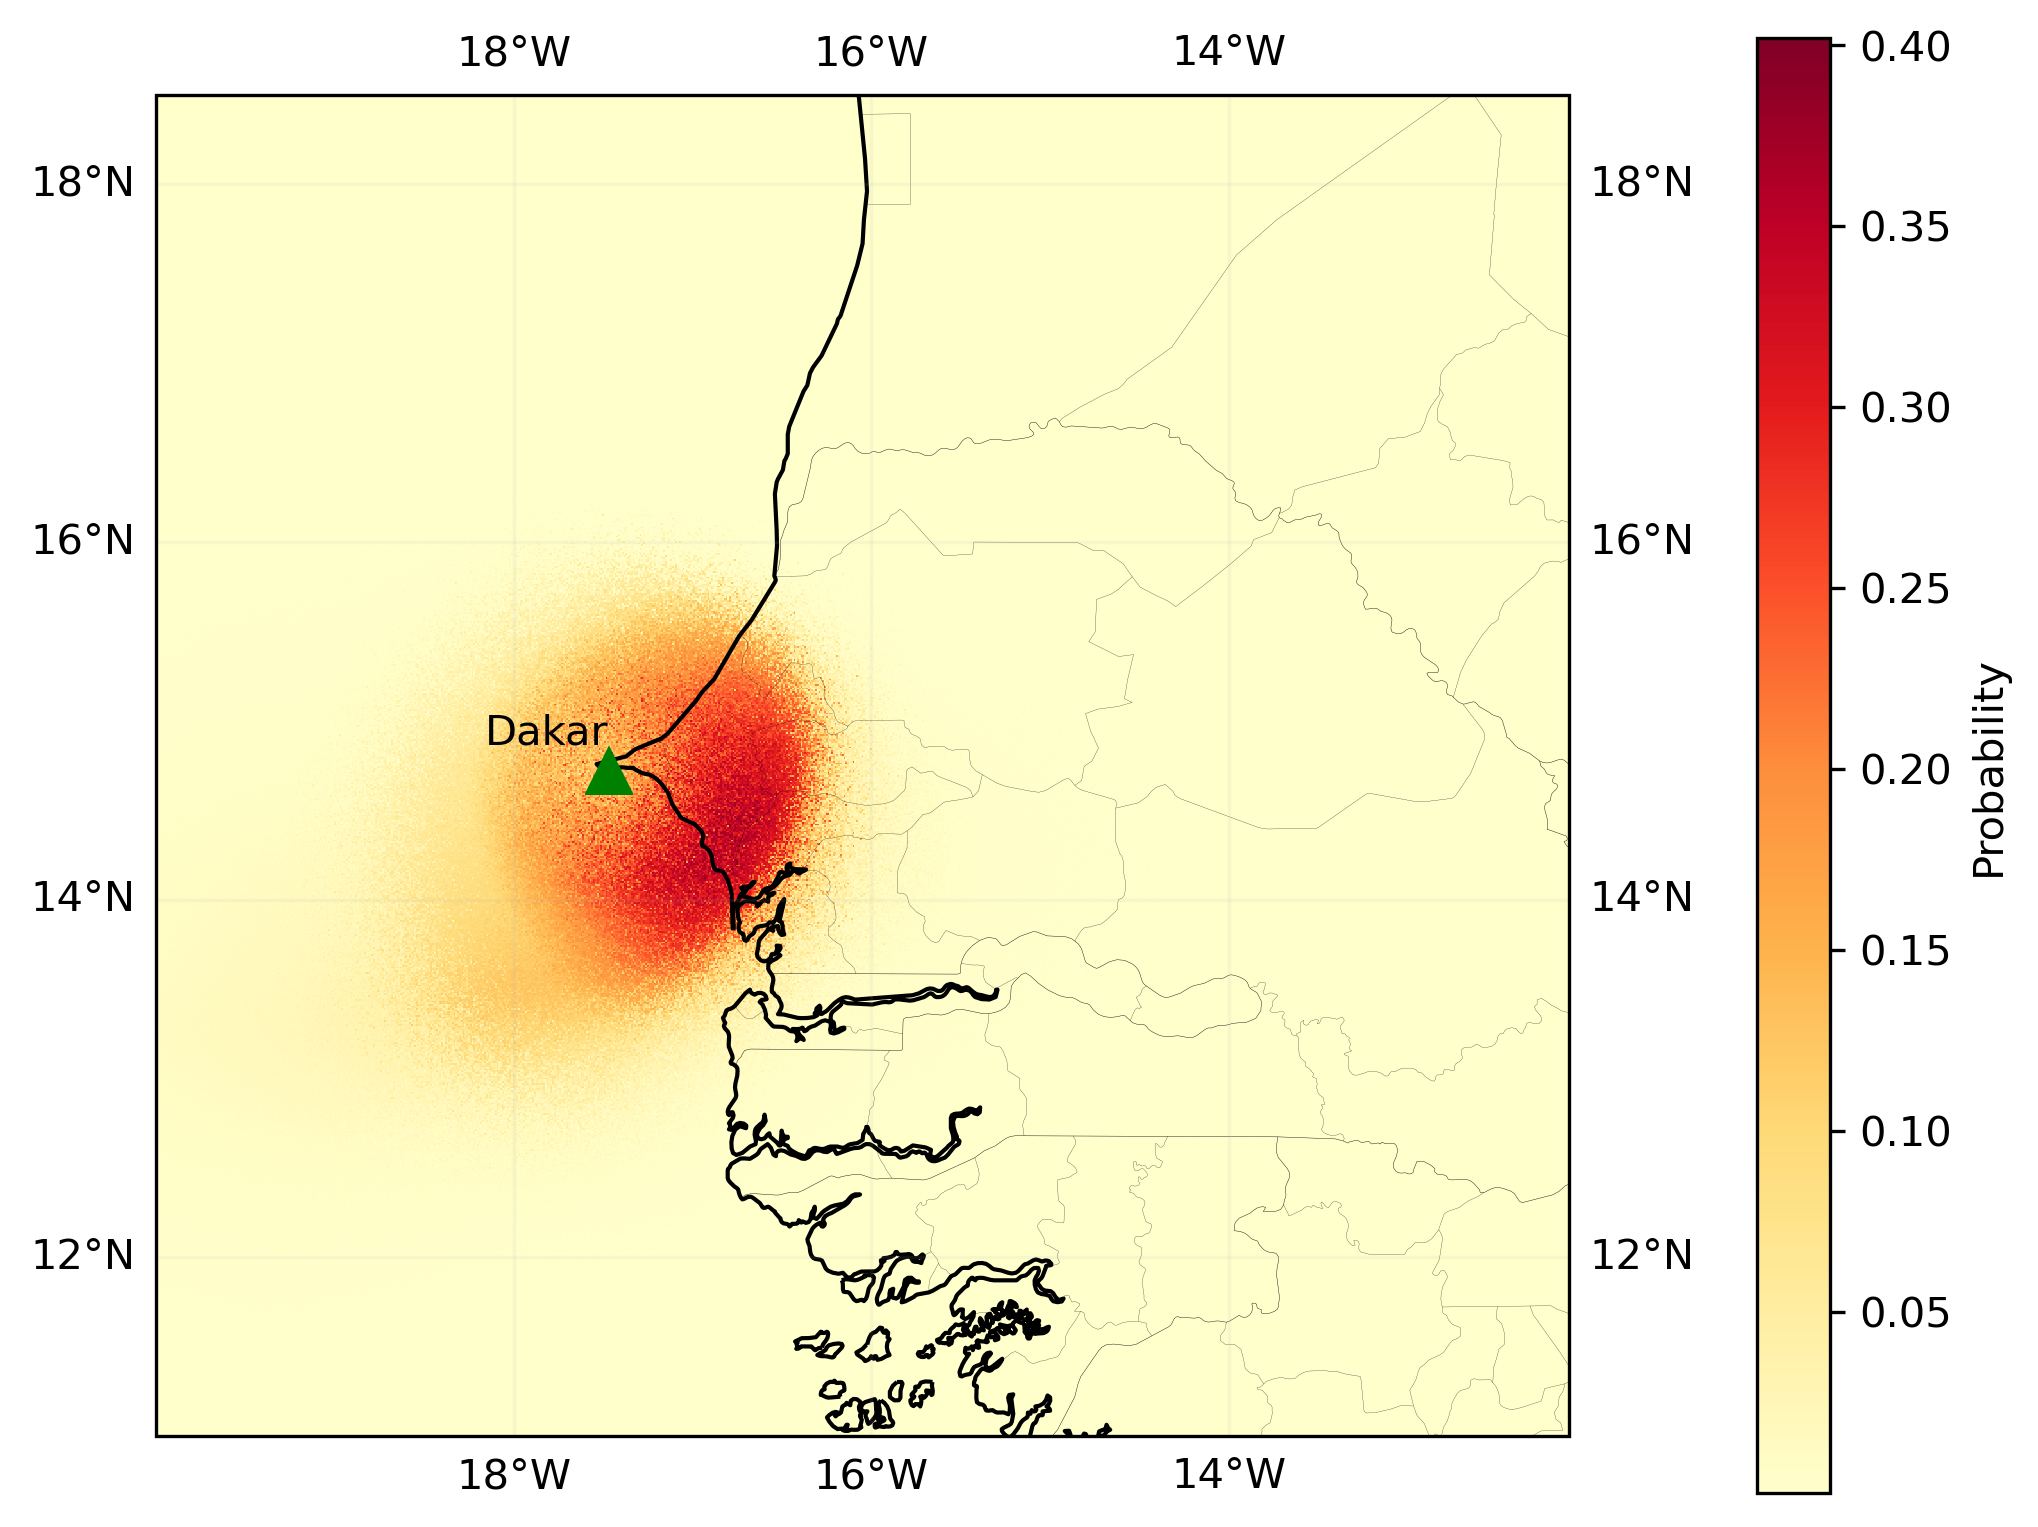

In [1599]:
# Define extent
# Create figure and axis
fig, ax = plt.subplots(figsize=(7, 10), dpi=300, subplot_kw={'projection': ccrs.PlateCarree()})

# Set map extent
ax.set_extent([-20, -12.1, 11, 18.5], crs=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.BORDERS, edgecolor='black', linewidth=0.1)
ax.add_feature(cfeature.COASTLINE, edgecolor='black')

# Force LAND to be white
ax.add_feature(cfeature.LAND, facecolor='white', edgecolor='black')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')

gl = ax.gridlines(xlocs=np.arange(-26, -8, 2), 
                  ylocs=np.arange(8, 23, 2), 
                  draw_labels=True, 
                  crs=ccrs.PlateCarree(),
                  alpha=0.1
                )

# Add administrative borders
admin_borders = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_1_states_provinces_lines',
    scale='10m',
    facecolor='none'
)

# display core data
ax.add_feature(admin_borders, edgecolor='black', linewidth=0.06)

pcm = plt.pcolormesh(lons, lats, probability, cmap="YlOrRd")
plt.colorbar(pcm, ax=ax, label='Probability', shrink=0.5, pad=0.1)

# contour = plt.contour(lons, lats, gaussian_probability, colors='white', levels=5)
# plt.clabel(contour, fontsize=8, fmt='%d')

# Plot a marker at Dakar's location
plt.plot(Dakar_lon, Dakar_lat, marker="^", color="green", markersize=10)
plt.text(Dakar_lon, Dakar_lat+0.1, "Dakar", ha="right", va="bottom")
plt.tight_layout()
plt.show()

In [1597]:
gaussian_probability = gaussian_filter(probability - pc, sigma=1)

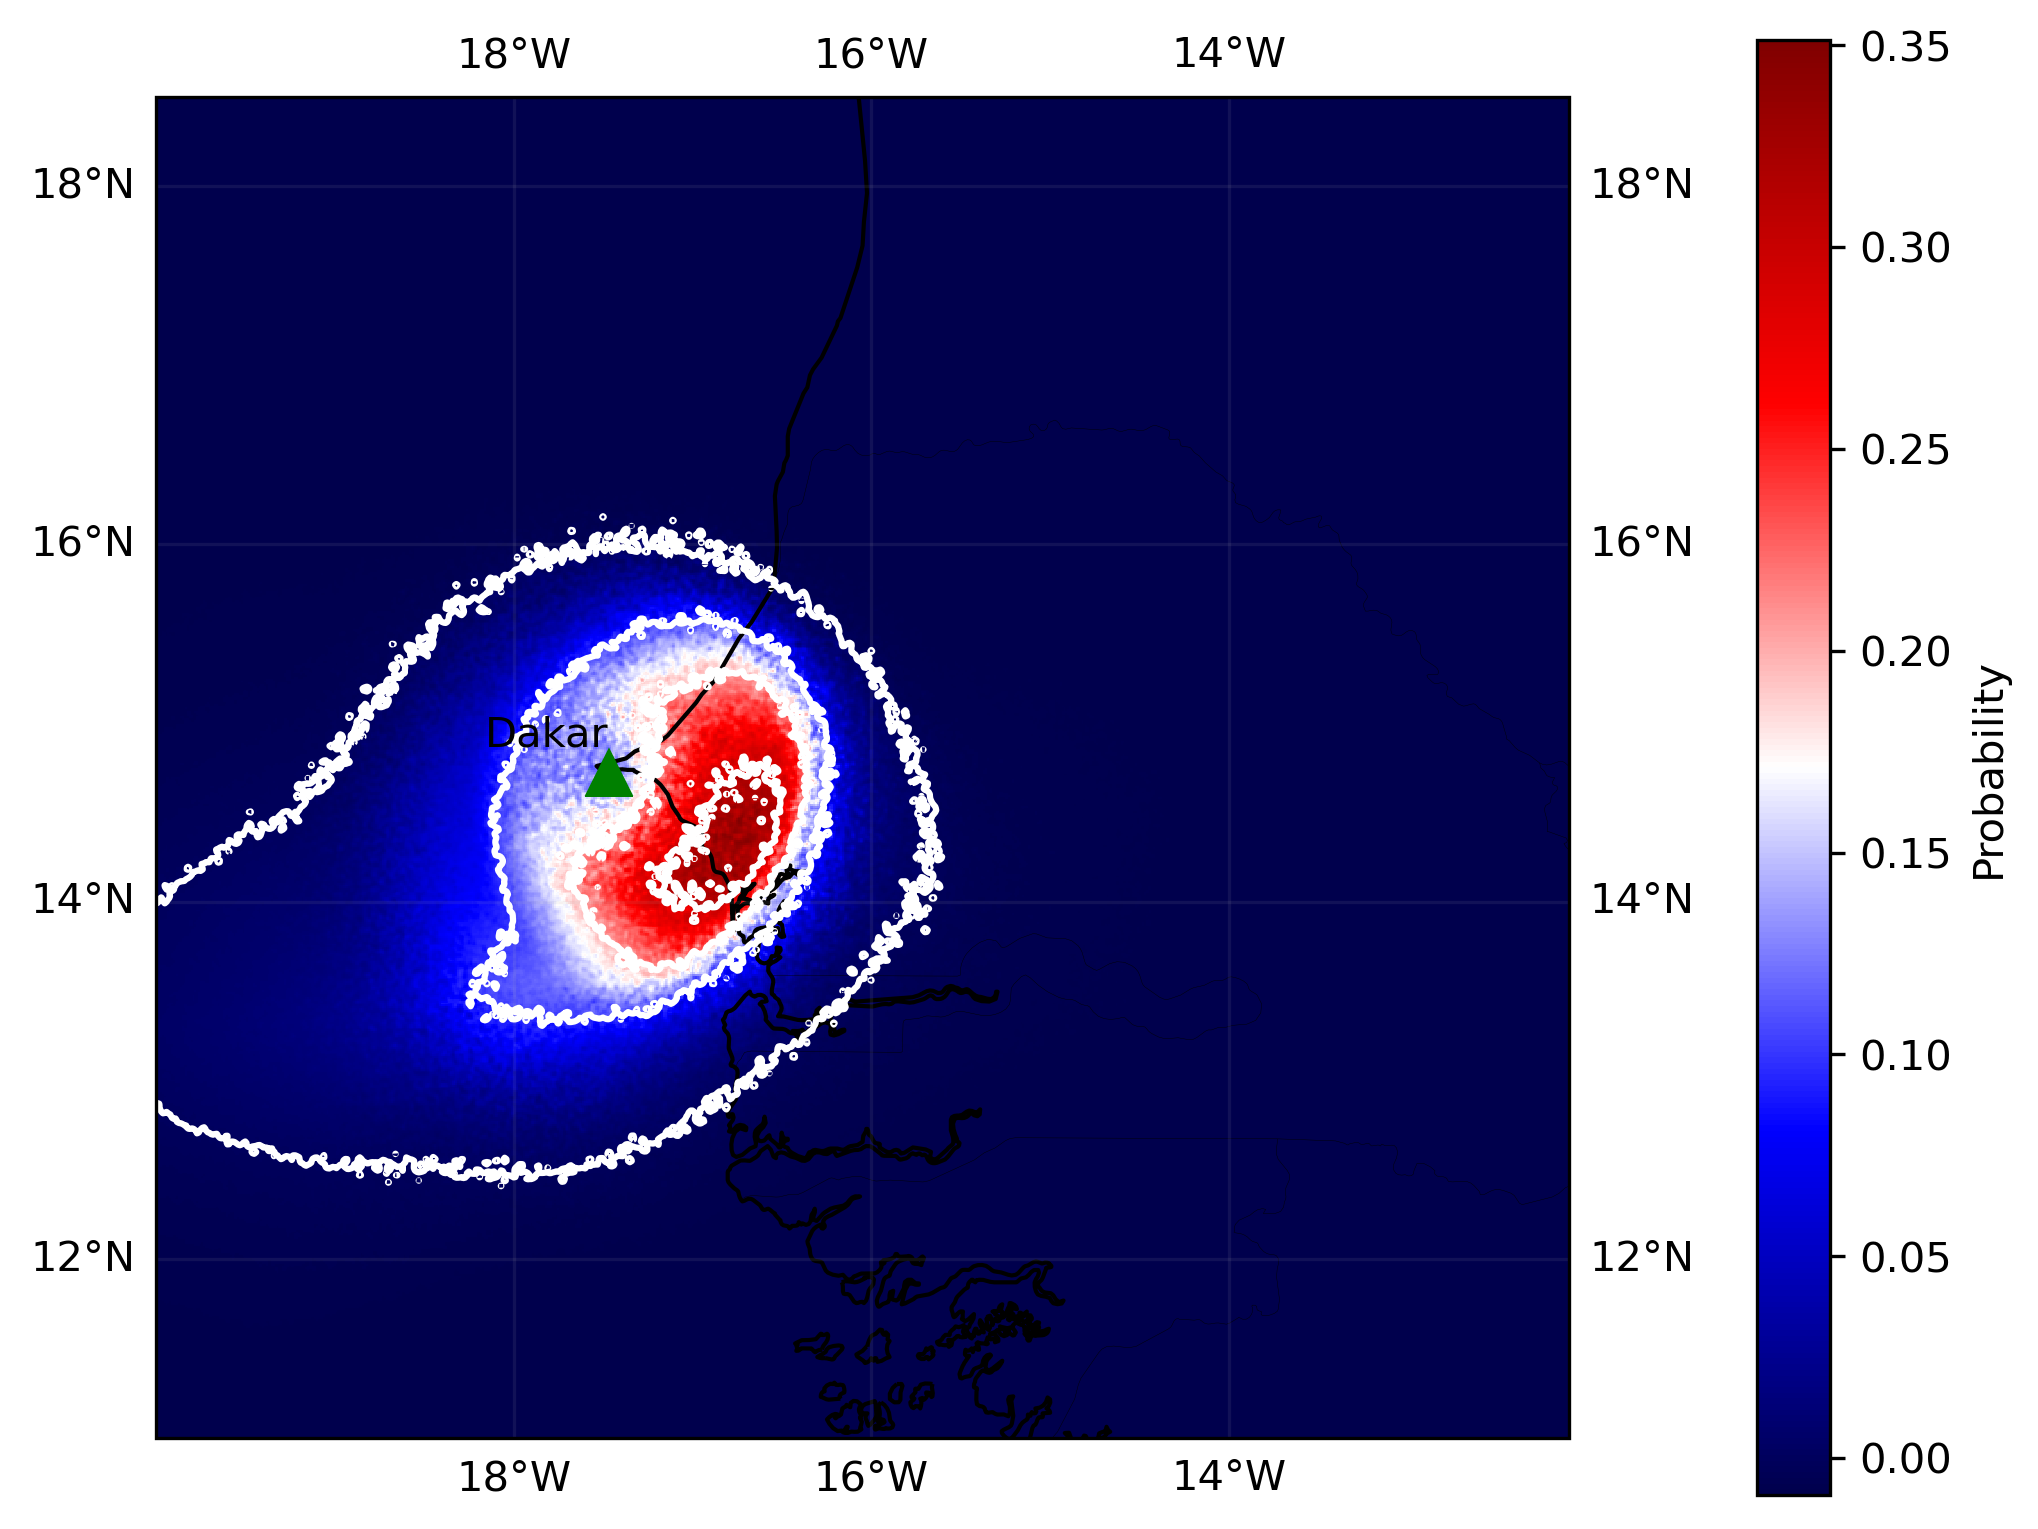

In [1598]:
# Create figure and axis
fig, ax = plt.subplots(figsize=(7, 10), dpi=300, subplot_kw={'projection': ccrs.PlateCarree()})

# Set map extent
ax.set_extent([-20, -12.1, 11, 18.5], crs=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.BORDERS, edgecolor='black', linewidth=0.1)
ax.add_feature(cfeature.COASTLINE, edgecolor='black')

# Force LAND to be white
ax.add_feature(cfeature.LAND, facecolor='white', edgecolor='black')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')

gl = ax.gridlines(xlocs=np.arange(-26, -8, 2), 
                  ylocs=np.arange(8, 23, 2), 
                  draw_labels=True, 
                  crs=ccrs.PlateCarree(),
                  alpha=0.1
                )

# Add administrative borders
admin_borders = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_1_states_provinces_lines',
    scale='50m',
    facecolor='none'
)


# display core data
ax.add_feature(admin_borders, edgecolor='black', linewidth=0.06)

pcm = ax.pcolormesh(lons, lats, gaussian_probability, cmap="seismic", transform=ccrs.PlateCarree())
plt.colorbar(pcm, ax=ax, label='Probability', shrink=0.5, pad=0.1)

contour = plt.contour(lons, lats, gaussian_probability, colors='white', levels=3)

# Plot a marker at Dakar's location
plt.plot(Dakar_lon, Dakar_lat, marker="^", color="green", markersize=10)
plt.text(Dakar_lon, Dakar_lat+0.1, "Dakar", ha="right", va="bottom")
plt.tight_layout()
plt.show()

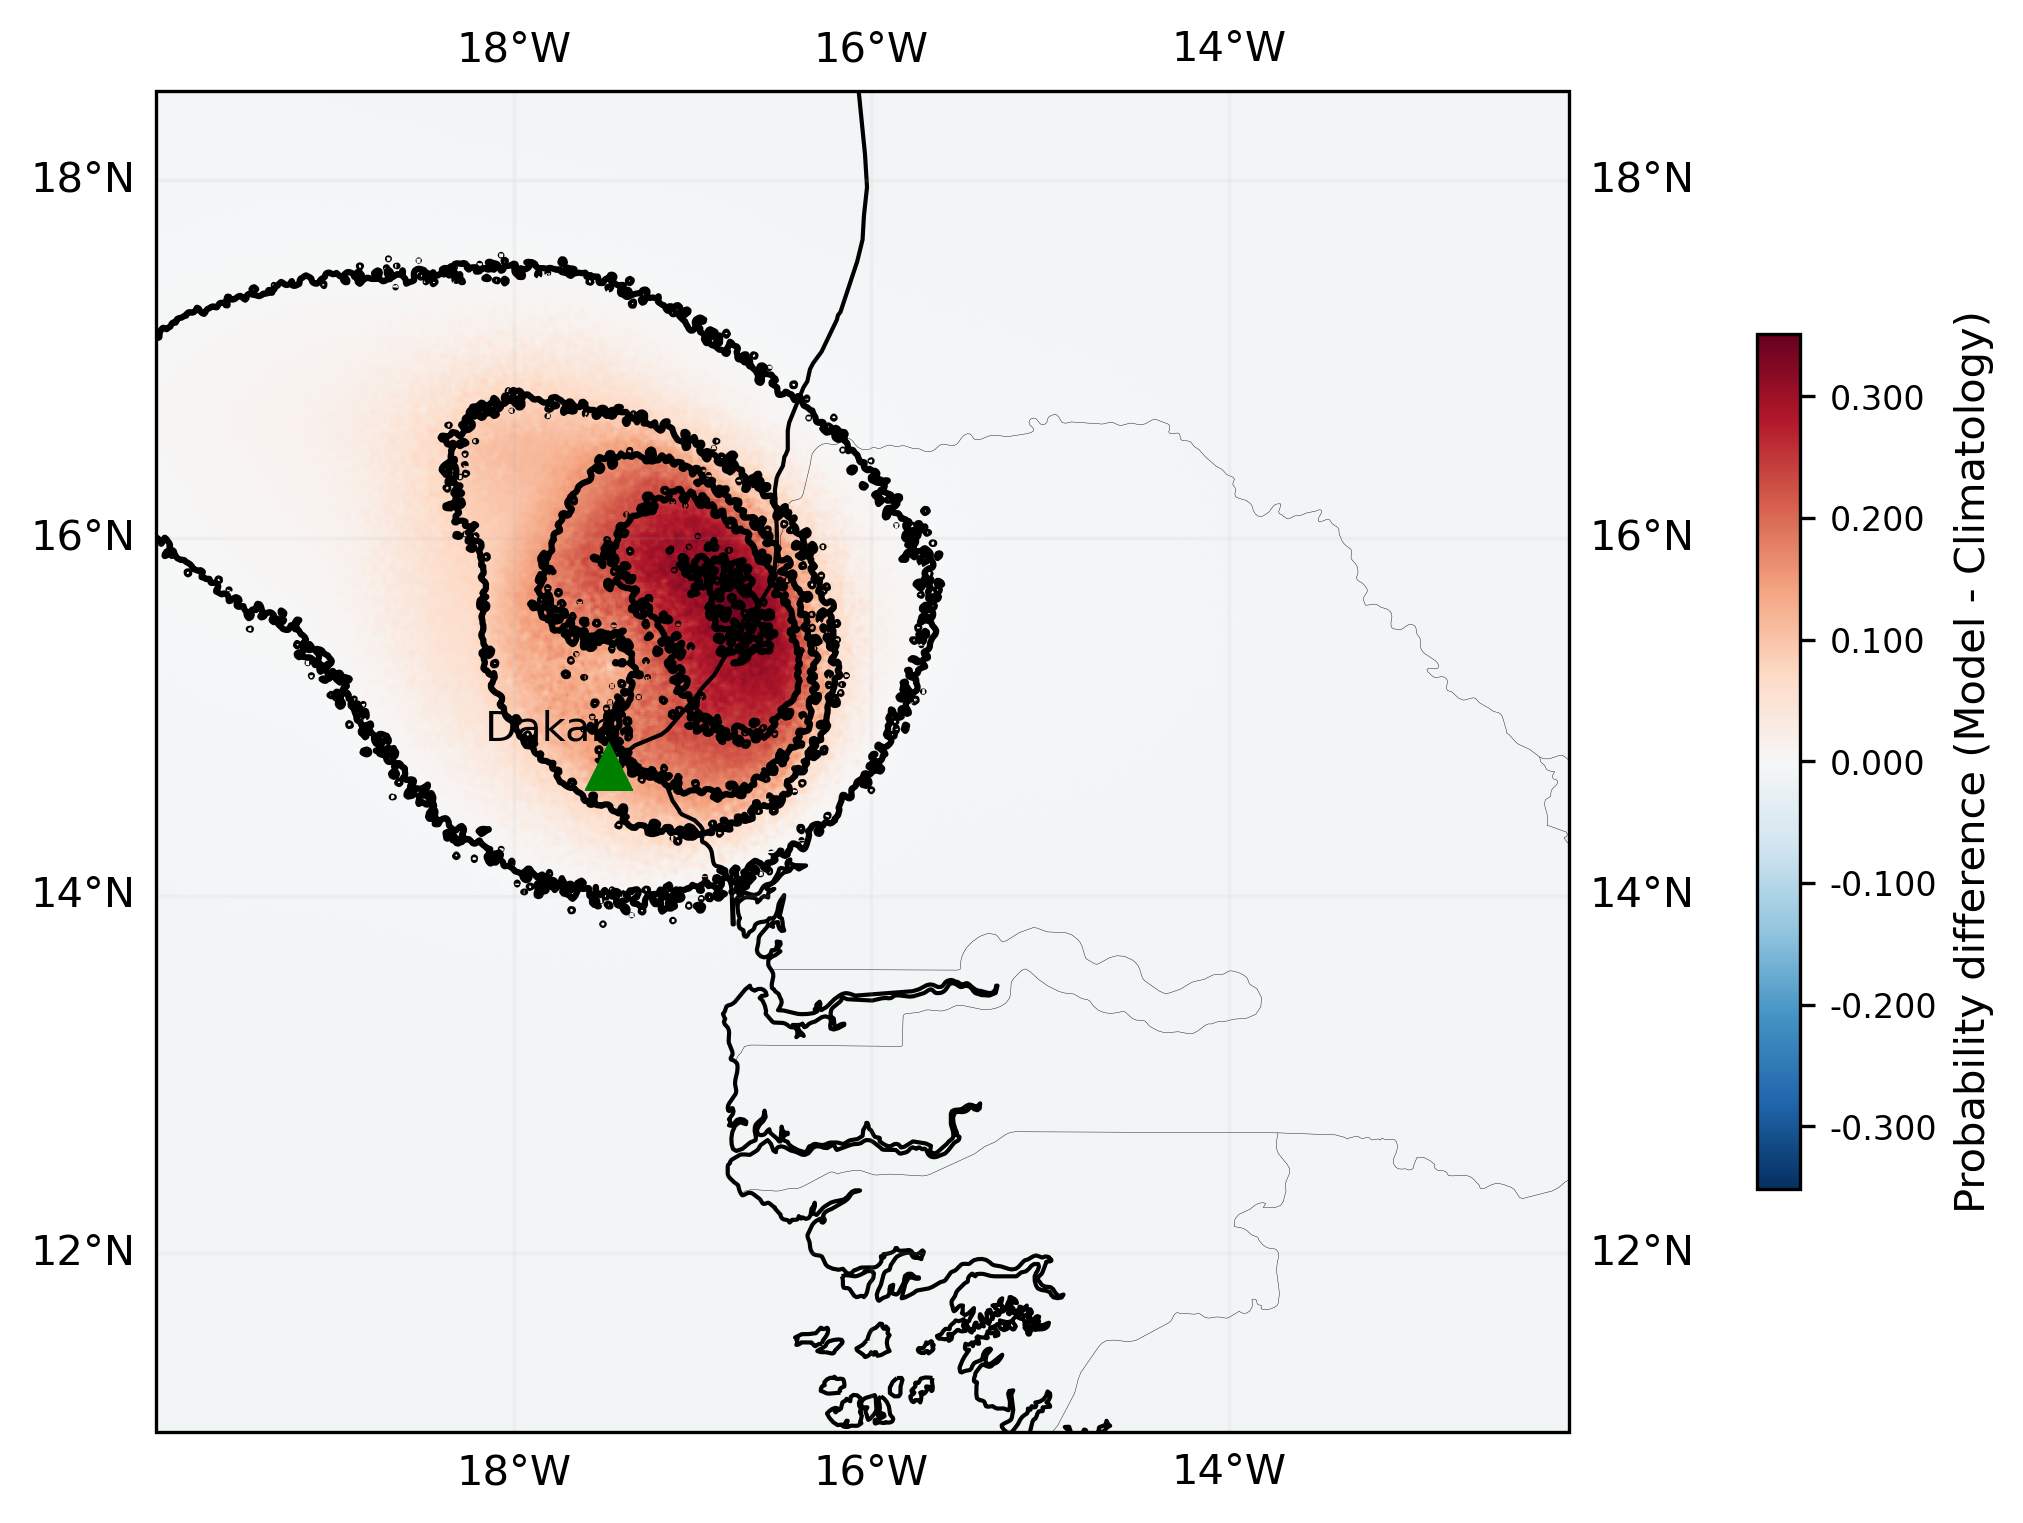

In [1600]:
import matplotlib.colors as mcolors

# Create figure and axis
fig, ax = plt.subplots(figsize=(7, 6), dpi=300, subplot_kw={'projection': ccrs.PlateCarree()})

# Set map extent
ax.set_extent([-20, -12.1, 11, 18.5], crs=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.BORDERS, edgecolor='black', linewidth=0.1)
ax.add_feature(cfeature.COASTLINE, edgecolor='black')

# Force LAND to be white
ax.add_feature(cfeature.LAND, facecolor='white', edgecolor='black')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')

gl = ax.gridlines(xlocs=np.arange(-26, -8, 2), 
                  ylocs=np.arange(8, 23, 2), 
                  draw_labels=True, 
                  crs=ccrs.PlateCarree(),
                  alpha=0.1
                )

# Add administrative borders
admin_borders = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_1_states_provinces_lines',
    scale='50m',
    facecolor='none'
)

# display core data
ax.add_feature(admin_borders, edgecolor='black', linewidth=0.06)

gaussian_probability = np.flipud(gaussian_probability)


# Centre colormap at zero
vmax = np.max(np.abs(gaussian_probability))
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

# Display core data with diverging colormap
pcm = ax.pcolormesh(
    lons, lats, gaussian_probability,
    cmap="RdBu_r",               # better for positive/negative data
    norm=norm,
    transform=ccrs.PlateCarree()
)

# Add formatted colourbar
cbar = plt.colorbar(pcm, ax=ax, shrink=0.5, pad=0.1)
cbar.set_label("Probability difference (Model - Climatology)", fontsize=10)
cbar.ax.tick_params(labelsize=8)
cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.3f}"))

# White contour lines for extra detail
contour = ax.contour(
    lons, lats, gaussian_probability,
    colors='black',
    levels=5,
    fontsize=0.1,
    transform=ccrs.PlateCarree()
)

# Plot a marker at Dakar's location
ax.plot(Dakar_lon, Dakar_lat, marker="^", color="green", markersize=10,
        transform=ccrs.PlateCarree())
ax.text(Dakar_lon, Dakar_lat + 0.1, "Dakar", ha="right", va="bottom",
        transform=ccrs.PlateCarree())


plt.tight_layout()
# plt.savefig(f"/localhome/home/mmmhr/EPS-Impact-Case-AI-Nowcasting/output/simulation/{hour}-{month}-{lead_time}.png", dpi=300)
plt.show()

In [1592]:
print(lats[0, 0], lats[-1, 0])


11.0 18.98999999999983


In [1594]:
print(lons[0, 0], lons[0, -1])


-20.0 -12.009999999998751


In [1593]:
print(gaussian_probability.shape)
print(gaussian_probability[0, :5])
print(gaussian_probability[-1, :5])


(800, 800)
[-0.00909267 -0.00909285 -0.009093   -0.009093   -0.00909301]
[-0.00876407 -0.00876613 -0.00876747 -0.00877113 -0.00877371]
